In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [10]:
DATASET_PATH = r"C:\Data Science\NEU-DET"

TRAIN_IMAGES = os.path.join(
    DATASET_PATH,
    "train",
    "images"
)

VAL_IMAGES = os.path.join(
    DATASET_PATH,
    "validation",
    "images"
)

In [11]:
print("Training path exists:", os.path.exists(TRAIN_IMAGES))
print("Validation path exists:", os.path.exists(VAL_IMAGES))

Training path exists: True
Validation path exists: True


In [12]:
# Load the training dataset

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_IMAGES,
    labels="inferred",
    label_mode="int",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

Found 1440 files belonging to 6 classes.


In [14]:
# Load validation dataset

In [15]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_IMAGES,
    labels="inferred",
    label_mode="int",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 360 files belonging to 6 classes.


In [16]:
#Check the class names

In [17]:
print("Classes:", train_ds.class_names)

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [18]:
#Look at same batch

In [19]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [20]:
#Check pixel value

In [21]:
print("Minimum pixel value:",
      tf.reduce_min(images).numpy())

print("Maximum pixel value:",
      tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 255.0


In [22]:
#Normaliztion pixel values

In [23]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [25]:
#Applying to the batch we have loaded

In [26]:
normalized_images = normalization_layer(images)

print("Minimum after normalization:",
      tf.reduce_min(normalized_images).numpy())

print("Maximum after normalization:",
      tf.reduce_max(normalized_images).numpy())

Minimum after normalization: 0.0
Maximum after normalization: 1.0


In [27]:
#Create data augementation:

In [28]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

In [29]:
#Visualize the Augmentation

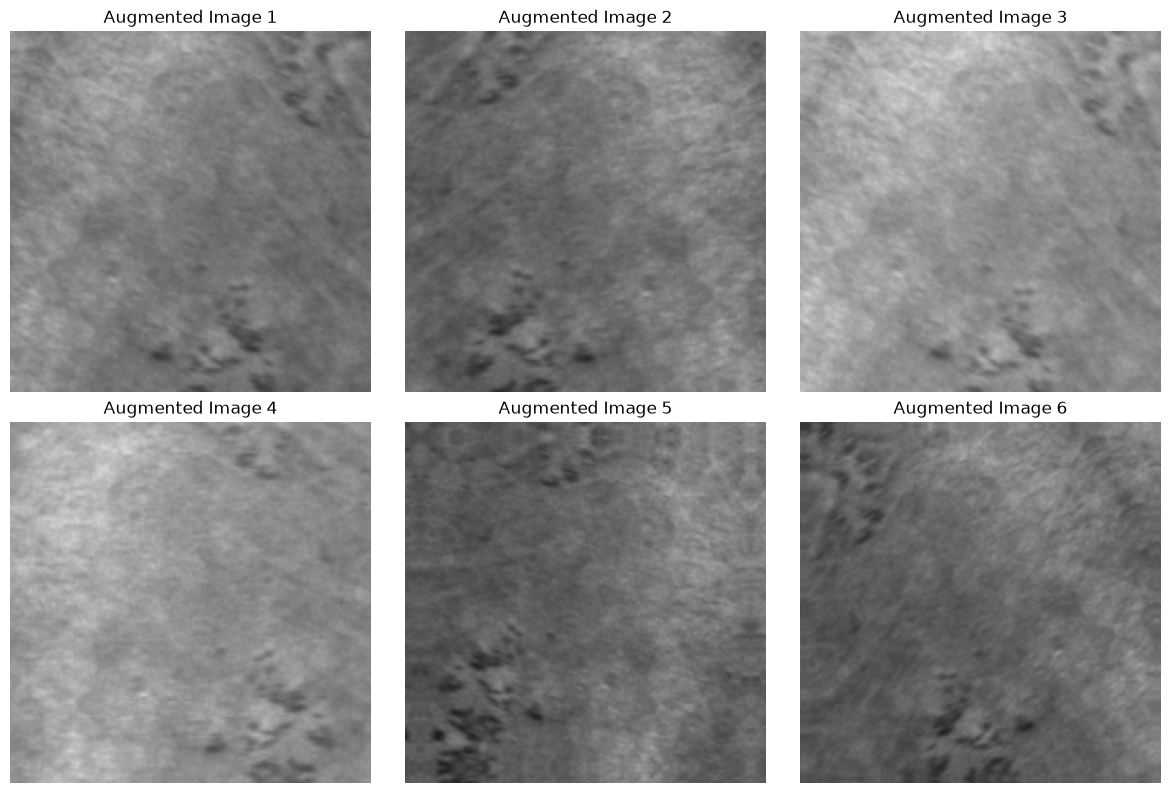

In [30]:
plt.figure(figsize=(12, 8))

sample_image = images[0]

for i in range(6):

    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )[0]

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        augmented_image.numpy().astype("uint8")
    )

    plt.title(f"Augmented Image {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
#The final preprocesiing pipline

In [32]:
train_ds = train_ds.map(
    lambda x, y: (
        normalization_layer(x),
        y
    )
)

val_ds = val_ds.map(
    lambda x, y: (
        normalization_layer(x),
        y
    )
)

In [33]:
#Prefetch the data

In [34]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [35]:
#Final verefication:

In [36]:
images, labels = next(iter(train_ds))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

print(
    "Minimum pixel value:",
    tf.reduce_min(images).numpy()
)

print(
    "Maximum pixel value:",
    tf.reduce_max(images).numpy()
)

Image shape: (32, 224, 224, 3)
Label shape: (32,)
Minimum pixel value: 0.00021007763
Maximum pixel value: 1.0
